In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
transactions = pd.read_csv("../data/tb_transaction.csv")
fees = pd.read_csv("../data/tb_transaction_fees.csv")
customers = pd.read_csv("../data/tb_cust.csv")

In [4]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

In [5]:
revenue_data = transactions.merge(
    fees[
        [
            "transaction_id",
            "fee_percentage",
            "fee_amount"
        ]
    ],
    on="transaction_id",
    how="left"
)

In [6]:
revenue_data.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,fee_percentage,fee_amount
0,65729,3302,2025-01-01,Bank Transfer,271040.36,0.5,1355.20
1,100855,8069,2025-01-01,Bank Transfer,389439.44,0.5,1947.20
2,43254,4752,2025-01-01,Shopping Payment,74162.57,1.0,741.63
3,43050,6521,2025-01-01,Bank Transfer,141149.29,0.5,705.75
4,46190,1833,2025-01-01,Shopping Payment,696860.92,1.0,6968.61


In [7]:
total_revenue = revenue_data["fee_amount"].sum()

print(f"Total Revenue: Rp {total_revenue:,.0f}")

Total Revenue: Rp 422,759,394


In [8]:
average_revenue = revenue_data["fee_amount"].mean()

print(
    f"Average Revenue per Transaction: "
    f"Rp {average_revenue:,.2f}"
)

Average Revenue per Transaction: Rp 2,113.80


In [9]:
revenue_data["fee_amount"].describe()

count    200000.000000
mean       2113.796972
std        1881.175504
min          50.000000
25%         965.477500
50%        1589.430000
75%        2621.397500
max       50000.000000
Name: fee_amount, dtype: float64

In [10]:
correlation = revenue_data[
    ["amount", "fee_amount"]
].corr()

correlation

,amount,fee_amount
amount,1.000000,0.916175
fee_amount,0.916175,1.000000


In [11]:
correlation_value = revenue_data[
    "amount"
].corr(
    revenue_data["fee_amount"]
)

print(
    f"Correlation: {correlation_value:.4f}"
)

Correlation: 0.9162


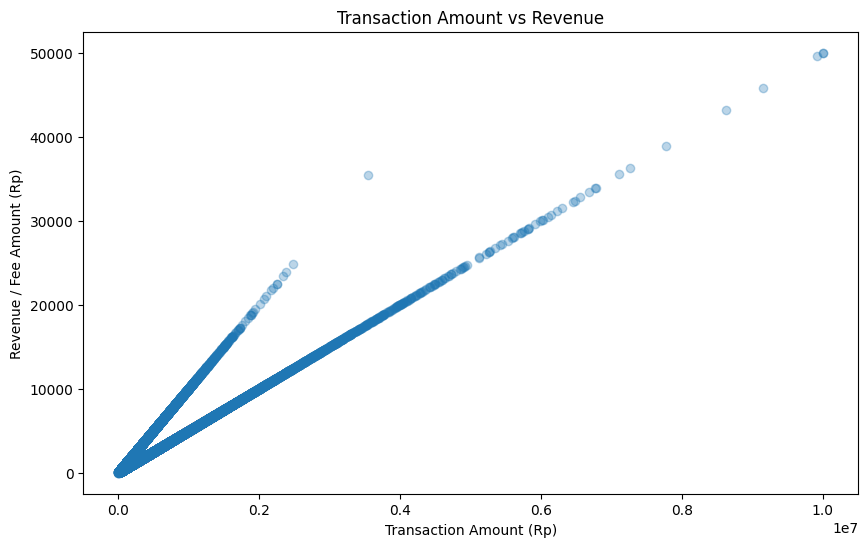

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    revenue_data["amount"],
    revenue_data["fee_amount"],
    alpha=0.3
)

plt.title("Transaction Amount vs Revenue")
plt.xlabel("Transaction Amount (Rp)")
plt.ylabel("Revenue / Fee Amount (Rp)")

plt.show()

In [13]:
revenue_by_type = (
    revenue_data
    .groupby("transaction_type")
    .agg(
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        revenue=("fee_amount", "sum"),
        average_revenue=("fee_amount", "mean")
    )
    .reset_index()
)

revenue_by_type

,transaction_type,transactions,transaction_value,revenue,average_revenue
0,Bank Transfer,79797,3.846155e+10,1.923077e+08,2409.96194
1,Shopping Payment,120203,2.304517e+10,2.304517e+08,1917.18727


In [14]:
revenue_by_type["revenue_contribution_pct"] = (
    revenue_by_type["revenue"]
    / revenue_by_type["revenue"].sum()
    * 100
)

revenue_by_type

,transaction_type,transactions,transaction_value,revenue,average_revenue,revenue_contribution_pct
0,Bank Transfer,79797,3.846155e+10,1.923077e+08,2409.96194,45.488695
1,Shopping Payment,120203,2.304517e+10,2.304517e+08,1917.18727,54.511305


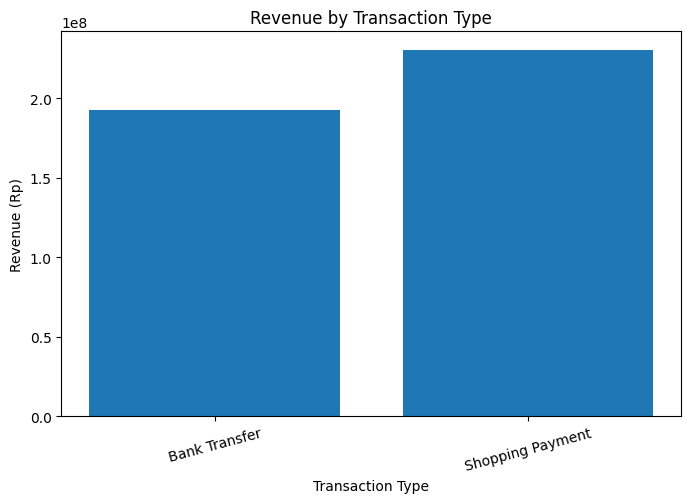

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    revenue_by_type["transaction_type"],
    revenue_by_type["revenue"]
)

plt.title("Revenue by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Revenue (Rp)")

plt.xticks(rotation=15)

plt.show()

In [16]:
revenue_customer = revenue_data.merge(
    customers[
        [
            "customer_id",
            "customer_segment",
            "city"
        ]
    ],
    on="customer_id",
    how="left"
)

In [17]:
revenue_by_segment = (
    revenue_customer
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        revenue=("fee_amount", "sum")
    )
    .reset_index()
)

revenue_by_segment

,customer_segment,customers,transactions,transaction_value,revenue
0,College Student,3396,69646,2.142624e+10,1.470695e+08
1,High School Student,2424,51832,1.585327e+10,1.091451e+08
2,Office Worker,3718,78522,2.422720e+10,1.665448e+08


In [18]:
revenue_by_segment["revenue_per_customer"] = (
    revenue_by_segment["revenue"]
    / revenue_by_segment["customers"]
)

In [19]:
revenue_by_segment[
    [
        "customer_segment",
        "customers",
        "transactions",
        "transaction_value",
        "revenue",
        "revenue_per_customer"
    ]
]

,customer_segment,customers,transactions,transaction_value,revenue,revenue_per_customer
0,College Student,3396,69646,2.142624e+10,1.470695e+08,43306.689134
1,High School Student,2424,51832,1.585327e+10,1.091451e+08,45026.842219
2,Office Worker,3718,78522,2.422720e+10,1.665448e+08,44794.193779


In [20]:
revenue_customer["month"] = (
    revenue_customer["transaction_date"]
    .dt.to_period("M")
)

In [21]:
monthly_revenue = (
    revenue_customer
    .groupby("month")
    .agg(
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        revenue=("fee_amount", "sum")
    )
    .reset_index()
)

monthly_revenue

,month,transactions,transaction_value,revenue
0,2025-01,11381,3.494364e+09,24131881.44
1,2025-02,10171,3.157613e+09,21673391.80
2,2025-03,11520,3.538607e+09,24302440.17
3,2025-04,10983,3.374262e+09,23255294.13
4,2025-05,11498,3.492758e+09,24115558.91
5,2025-06,10750,3.293396e+09,22834964.09
6,2025-07,11288,3.501722e+09,24068182.26
7,2025-08,11471,3.501928e+09,24077514.75
8,2025-09,11068,3.417418e+09,23392353.87
9,2025-10,11296,3.454806e+09,23709861.36


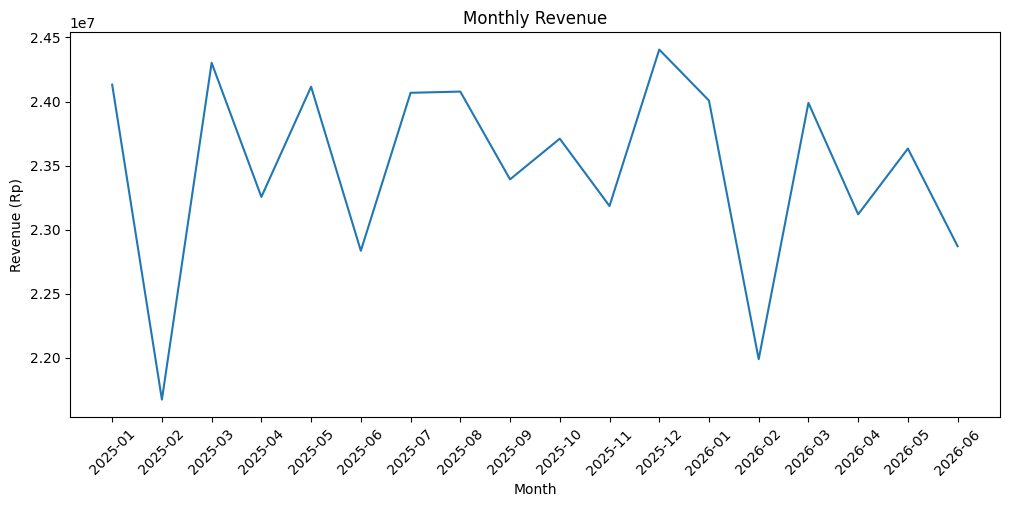

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (Rp)")

plt.xticks(rotation=45)

plt.show()

In [23]:
monthly_revenue["revenue_growth_pct"] = (
    monthly_revenue["revenue"]
    .pct_change()
    * 100
)

In [24]:
monthly_revenue[
    [
        "month",
        "revenue",
        "revenue_growth_pct"
    ]
]

,month,revenue,revenue_growth_pct
0,2025-01,24131881.44,NaN
1,2025-02,21673391.80,-10.187725
2,2025-03,24302440.17,12.130304
3,2025-04,23255294.13,-4.308810
4,2025-05,24115558.91,3.699221
5,2025-06,22834964.09,-5.310243
6,2025-07,24068182.26,5.400570
7,2025-08,24077514.75,0.038775
8,2025-09,23392353.87,-2.845646
9,2025-10,23709861.36,1.357313


In [25]:
revenue_drivers = revenue_customer.agg(
    total_transaction_value=("amount", "sum"),
    total_transactions=("transaction_id", "count"),
    total_revenue=("fee_amount", "sum")
)

revenue_drivers

,amount,transaction_id,fee_amount
total_transaction_value,6.150671e+10,NaN,NaN
total_transactions,NaN,200000.0,NaN
total_revenue,NaN,NaN,4.227594e+08


In [26]:
effective_fee_rate = (
    revenue_customer["fee_amount"].sum()
    / revenue_customer["amount"].sum()
)

print(
    f"Effective Fee Rate: "
    f"{effective_fee_rate:.4%}"
)

Effective Fee Rate: 0.6873%
